In [ ]:
import pandas as pd
from pathlib import Path
import copy

import numpy as np
import torch
from tqdm import tqdm
import pickle

from mist.utils.plot_utils import *
from rdkit import Chem
from rdkit.Chem import Draw, MolFromSmiles
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.DataStructs.cDataStructs import ExplicitBitVect

import mist.utils as utils
import mist.subformulae.assign_subformulae as assign_subformulae
import mist.models.base as base
import mist.data.datasets as datasets
import mist.data.featurizers as featurizers
import mist.data.data as data

In [100]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/neims/"
mgf_input = "../data/neims/gecko_EIMS_spectra/neims_spectra.mgf"
labels = "../data/neims/gecko_EIMS_spectra/neims_labels.tsv"
smiles_input = "../data/neims/gecko_EIMS_spectra/lookup_smiles.txt"

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)


In [101]:

subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=32,
    feature_id="FEATURE_ID",
    debug=False
)

0it [00:00, ?it/s]

20000it [00:00, 21736.51it/s]


[[4.40000000e+01 1.00000000e+00]
 [4.30000000e+01 9.35347462e-01]
 [6.90000000e+01 8.95992635e-01]
 [4.20000000e+01 8.92073874e-01]
 [5.50000000e+01 8.72789643e-01]
 [5.60000000e+01 8.12194348e-01]
 [9.70000000e+01 7.49374113e-01]
 [5.70000000e+01 7.33169515e-01]
 [4.60000000e+01 6.91721388e-01]
 [9.60000000e+01 6.71156055e-01]
 [7.10000000e+01 6.65163470e-01]
 [3.00000000e+01 6.54544443e-01]
 [5.30000000e+01 6.53013343e-01]
 [6.80000000e+01 6.09402471e-01]
 [4.10000000e+01 5.84244248e-01]
 [1.01000000e+02 5.80807487e-01]
 [5.40000000e+01 5.66852116e-01]
 [9.40000000e+01 5.60637418e-01]
 [8.50000000e+01 5.57055033e-01]
 [8.60000000e+01 5.21797156e-01]
 [6.70000000e+01 5.16009948e-01]
 [4.00000000e+01 5.13091866e-01]
 [4.70000000e+01 5.11137224e-01]
 [5.20000000e+01 5.02247202e-01]
 [7.00000000e+01 4.97239628e-01]
 [2.68000000e+02 4.95222420e-01]
 [9.50000000e+01 4.87070054e-01]
 [7.30000000e+01 4.68208521e-01]
 [8.20000000e+01 4.55200184e-01]
 [6.50000000e+01 4.49668992e-01]
 [8.400000

10000it [00:01, 5886.67it/s]


In [102]:
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)
for key, val in kwargs.items():
    print(key, val)

fp_names ['morgan4096']
binarization_thresh 0.5
loss_fn cosine
magma_aux_loss True
iterative_preds growing
iterative_loss_weight 0.4
shuffle_train False
magma_loss_lambda 8.0
form_embedder pos-cos
debug False
seed 1
save_dir results/canopus_fp_mist/split_0
magma_folder data/paired_spectra/canopus_train/magma_outputs/magma_tsv/
subform_folder data/paired_spectra/canopus_train/subformulae/subformulae_default/
labels_file data/paired_spectra/canopus_train/labels.tsv
spec_folder data/paired_spectra/canopus_train/spec_files/
split_file data/paired_spectra/canopus_train/splits/canopus_hplus_100_0.tsv
augment_data True
augment_prob 0.5
remove_weights exp
inten_transform float
inten_prob 0.1
remove_prob 0.5
forward_labels data/paired_spectra/canopus_train/aug_iceberg_canopus_train/biomols_filtered_smiles_canopus_train_labels.tsv
forward_aug_folder data/paired_spectra/canopus_train/aug_iceberg_canopus_train/canopus_hplus_100_0/subforms/
frac_orig 0.6
learning_rate 0.00077
weight_decay 1e-07
lr_

In [103]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

In [104]:
# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

10000it [00:00, 203469.70it/s]
10000it [00:00, 319897.49it/s]
10000it [00:00, 8089303.76it/s]


In [105]:
arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]
fp_file_out = f'../data/neims/{fp_name}.txt'
np.savetxt(fp_file_out, arr, fmt="%d")

In [106]:
smiles = pd.read_csv('../data/neims/gecko_EIMS_spectra/smiles.csv')['SMILES'].values
smiles

array(['C1(=O)C([N+](=O)[O-])(OO)C(O[N+](=O)[O-])(C(OO))OOC(=O)C1',
       'CC(=O)C(O[N+](=O)[O-])C(C)(C)C(O[N+](=O)[O-])(C)C(=O)(O)',
       'C1(=O)OC1C(OO)(C)C(=O)(OO)', ...,
       'C(=O)(OO)C([N+](=O)[O-])(O[N+](=O)[O-])C(C(=O))OOC(=O)C(=O)',
       'C(=O)(OO)C(=O)C(OO)C([N+](=O)[O-])(C(=O)(O))OOC(=O)',
       'CC(=O)C(OO)CC(=O)C(O)CC(O)'], dtype=object)

In [107]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)

In [ ]:
def numpy_to_rdkit_bitvec(arr_row):
    bitvec = ExplicitBitVect(len(arr_row))
    for i, bit in enumerate(arr_row):
        if bit == 1:
            bitvec.SetBit(i)
    return bitvec

predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]

In [109]:
similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

In [110]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")

10000 valid similarities
Mean Tanimoto similarity: 0.164
Median Tanimoto similarity: 0.167


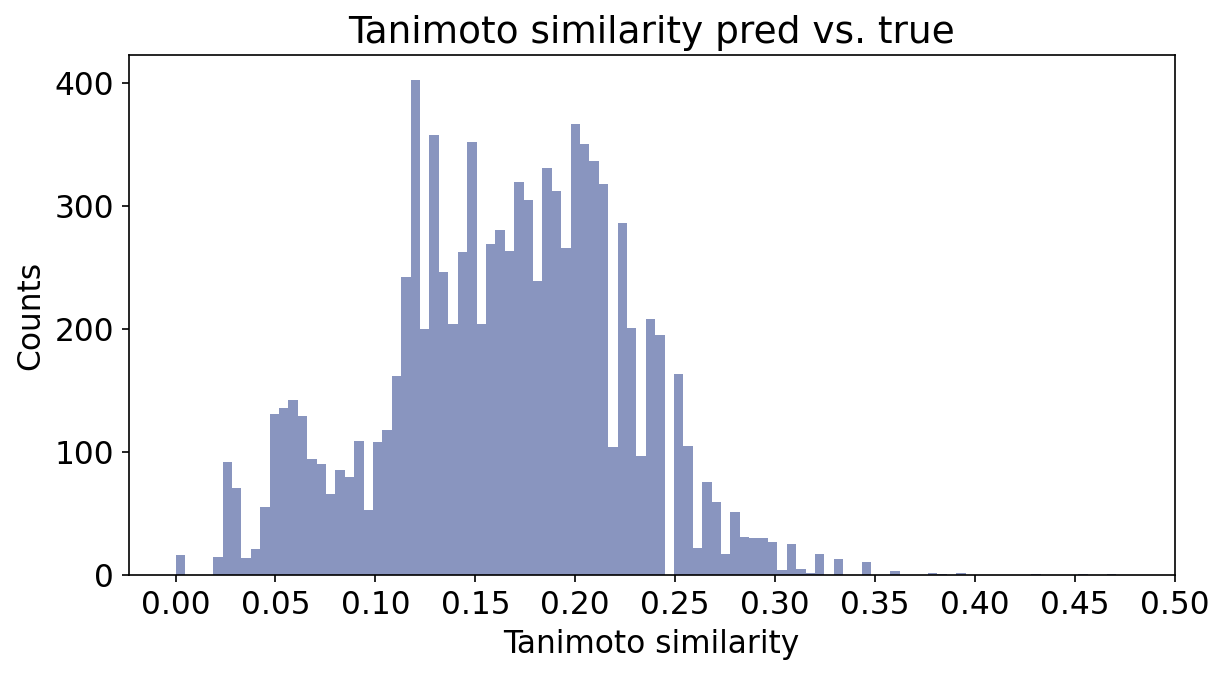

In [111]:
import matplotlib.pyplot as plt
FS = 15
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 
                                   'Bitstream Vera Sans', 'sans-serif']
plt.rcParams.update({'font.size': FS})
plt.figure(figsize=(9,4.5), dpi=150)
plt.hist(valid_sims, bins=100, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
plt.xticks(np.linspace(0, 0.5, 11))
plt.show()

In [112]:
contrast_savedir = Path("../quickstart/model_predictions")
contrast_model = torch.load(contrast_ckpt, map_location=torch.device("cpu"))
contrast_savedir.mkdir(exist_ok=True)

main_hparams = contrast_model["hyper_parameters"]
main_hparams['labels_file'] = labels
main_hparams['device'] = "cpu"
main_hparams['allow_none_smiles'] = True
main_hparams['num_workers'] = 0
main_hparams['subform_folder'] = subform_dir

base_params = main_hparams["base_model_hparams"]
main_hparams["base_model_hparams"] = copy.deepcopy(base_params)
base_params.update(main_hparams)
kwargs = base_params

device = torch.device("cpu")
model = base.build_model(**kwargs)
model.load_state_dict(contrast_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.main_model.spec_features(mode="test")
kwargs['mol_features'] = "none"

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))

10000it [00:00, 167611.25it/s]
10000it [00:00, 28601.09it/s]
10000it [00:00, 8729040.58it/s]


In [ ]:
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)

test_loader = datasets.SpecDataModule.get_paired_loader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=kwargs.get("num_workers"),
)

# Encode specs
encoded_specs, names = [], []
with torch.no_grad():
    model = model.to(device)
    model = model.eval()
    for spectra_batch in tqdm(test_loader):
        spectra_batch = {
            k: v.to(device=device, non_blocking=True) if hasattr(v, "to") else v
            for k, v in spectra_batch.items()
        }
        outputs = model.encode_spectra(spectra_batch)
        contrast_out = outputs[1]["contrast"].detach().cpu()
        encoded_specs.append(contrast_out)
        names.append(spectra_batch["names"])

    names = np.concatenate(names)
    stacked_spectra = torch.cat(encoded_specs, 0).numpy()

new_entry = {}
new_entry["args"] = main_hparams
new_entry["embeds"] = stacked_spectra
new_entry["names"] = names

 18%|█▊        | 14/79 [00:12<00:56,  1.14it/s]

In [ ]:
new_labels = pd.read_csv(labels, sep="\t").astype(str)

In [ ]:
# Contrastive embeddings
name_to_embed = {name: embed for name, embed in zip(new_entry['names'], new_entry['embeds'])}
name_to_formula = {name: formula for name, formula in zip(new_labels['spec'], new_labels['formula'])}
kwargs['mol_features'] = model.main_model.mol_features(mode="test")
kwargs['fp_names'] = contrast_model['hyper_parameters']['base_model_hparams']['fp_names']
paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

# Extract candidate list file
smi_list = smiles_input
all_smi = [i.strip() for i in open(smi_list, "r").readlines()]
forms = [utils.form_from_smi(i) for i in all_smi]
ikeys = [utils.inchikey_from_smiles(i) for i in all_smi]
form_to_smi = {i: [] for i in set(forms)}
for form, smi, ikey in zip(forms, all_smi, ikeys):
    form_to_smi[form].append((smi, ikey))

In [ ]:
name_to_output = {}
for name, formula in name_to_formula.items():
    embed = name_to_embed[name]
    #print(name, formula, embed)
    candidates = form_to_smi[formula]
    print(name, formula, candidates)
    cand_smis, cand_ikeys = zip(*candidates)
    mol_list = [data.Mol.MolFromSmiles(i) for i in cand_smis]
    fp_list = [paired_featurizer.featurize_mol(i) for i in mol_list]
    fp_list = torch.from_numpy(np.vstack(fp_list)) 
    fp_loader = torch.utils.data.DataLoader(fp_list, batch_size=128, shuffle=False)
    encoded_mols = []
    with torch.no_grad():
            model = model.to(device)
            model = model.eval()
            for fp_batch in tqdm(fp_loader):
                batch = {"mols": fp_batch.to(device)}

                outputs = model.encode_mol(batch)
                contrast_out = outputs[1]["contrast"].detach().cpu()
                encoded_mols.append(contrast_out)
            stacked_mols = torch.cat(encoded_mols, 0).numpy()
    cos_dist = np.dot(embed, stacked_mols.T) / (np.linalg.norm(embed) * np.linalg.norm(stacked_mols, axis=1))
    arg_order = np.argsort(cos_dist)
    mol_list = np.array(cand_smis)[arg_order]
    name_to_output[name] = mol_list


KeyError: 'C6H6N2O13'

In [ ]:
for k, v in name_to_output.items():
    # Print name and formula
    print(f"Spectrum: {k}", name_to_formula[k])
    # Display top 3 smiles using rdkit Chem mol to grid images
    if len(v) == 0:
        print("No cands for this formula")
        continue
    mol_objs = [Chem.MolFromSmiles(i) for i in v[:3]]
    # Add text below for rank
    img = Draw.MolsToGridImage(mol_objs, molsPerRow=3, subImgSize=(300, 300)
                                 , legends=[f"Rank {i+1}" for i in range(len(mol_objs))]
                               )
    display(img)
    print("\n\n")